<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/PR_P9_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
# Define data directories (placeholder - replace with your actual dataset path)
# Example structure: dataset/train/with_mask, dataset/train/without_mask, etc.
data_dir = './dataset'

# Create dummy directories and files if they don't exist, for demonstration
if not os.path.exists(data_dir):
    os.makedirs(os.path.join(data_dir, 'train', 'with_mask'))
    os.makedirs(os.path.join(data_dir, 'train', 'without_mask'))
    os.makedirs(os.path.join(data_dir, 'validation', 'with_mask'))
    os.makedirs(os.path.join(data_dir, 'validation', 'without_mask'))
    # Create dummy files
    from PIL import Image
    dummy_img = Image.new('RGB', (128, 128), color = 'red')
    dummy_img.save(os.path.join(data_dir, 'train', 'with_mask', 'dummy_1.jpg'))
    dummy_img.save(os.path.join(data_dir, 'train', 'without_mask', 'dummy_2.jpg'))
    dummy_img.save(os.path.join(data_dir, 'validation', 'with_mask', 'dummy_3.jpg'))
    dummy_img.save(os.path.join(data_dir, 'validation', 'without_mask', 'dummy_4.jpg'))
    print("Dummy dataset structure created.")


# Image dimensions and batch size
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for validation data (no augmentation)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'train'),
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' for 2 classes: with_mask, without_mask
)

validation_generator = validation_datagen.flow_from_directory(
    os.path.join(data_dir, 'validation'),
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("Dataset generators prepared.")

Dummy dataset structure created.
Found 2 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Dataset generators prepared.


In [3]:
# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5), # Add dropout for regularization
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid') # Binary classification (mask/no mask)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()
print("Model built and compiled successfully.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Model built and compiled successfully.


### 4. Model Training

Now, we will train the compiled CNN model using the `train_generator` for training data and `validation_generator` for validation data. We'll specify the number of epochs and steps per epoch.

In [4]:
# Train the model
EPOCHS = 10 # You can adjust this number

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Model training complete.")

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.6511 - val_accuracy: 0.5000 - val_loss: 0.7431
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.5000 - loss: 0.7616 - val_accuracy: 0.5000 - val_loss: 0.7293
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5000 - loss: 0.7099 - val_accuracy: 0.5000 - val_loss: 0.7155
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.5000 - loss: 0.7364 - val_accuracy: 0.5000 - val_loss: 0.7021
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5000 - loss: 0.6399 - val_accuracy: 0.5000 - val_loss: 0.7053
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step - accuracy: 0.5000 - loss: 0.6624 - val_accuracy: 0.5000 - val_loss: 0.7002
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5000 - loss: 0.6505 - val_accuracy: 0.5000 - val_loss: 0.7018
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5000 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.

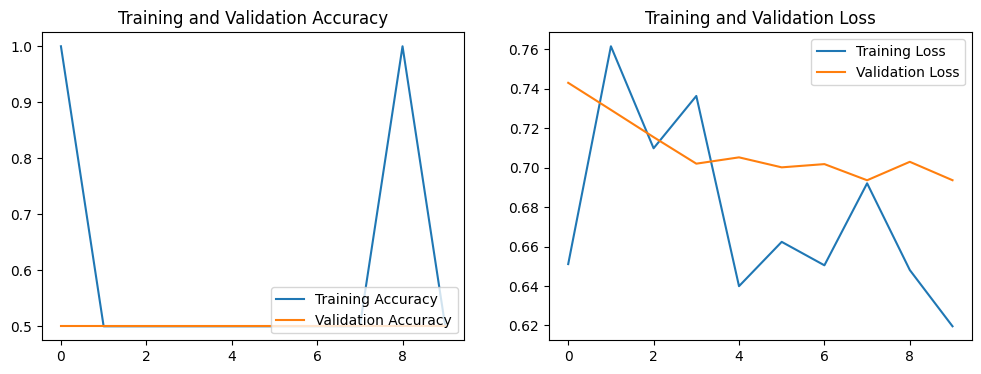

Model evaluation plots generated.


In [5]:
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

print("Model evaluation plots generated.")

In [6]:
# Save the trained model
model_save_path = 'mask_detector_model.keras'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to mask_detector_model.keras


Model loaded from mask_detector_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Prediction for sample image: Mask Detected with 51.61% confidence.


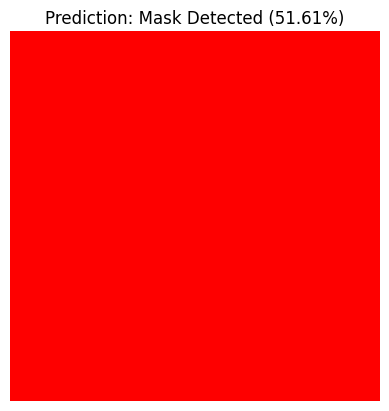

Demonstration of model prediction complete.


In [7]:
# Load the saved model
loaded_model = tf.keras.models.load_model(model_save_path)
print(f"Model loaded from {model_save_path}")

def preprocess_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array = img_array / 255.0  # Rescale to [0,1]
    return img_array

# Example: Predict on a dummy image from the 'with_mask' category
sample_image_path = os.path.join(data_dir, 'validation', 'with_mask', 'dummy_3.jpg')

if os.path.exists(sample_image_path):
    processed_image = preprocess_image(sample_image_path)
    prediction = loaded_model.predict(processed_image)

    # The output is a probability. If > 0.5, it's 'with_mask', otherwise 'without_mask'
    if prediction[0] > 0.5:
        result = "Mask Detected"
        confidence = prediction[0][0] * 100
    else:
        result = "No Mask Detected"
        confidence = (1 - prediction[0][0]) * 100

    print(f"Prediction for sample image: {result} with {confidence:.2f}% confidence.")

    # Display the image and prediction
    img_to_show = tf.keras.preprocessing.image.load_img(sample_image_path)
    plt.imshow(img_to_show)
    plt.title(f"Prediction: {result} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
else:
    print(f"Sample image not found at {sample_image_path}. Cannot perform prediction demo.")

print("Demonstration of model prediction complete.")